# EDA + teste do pipeline — Medical Abstracts TC Corpus

Dataset: [saharalaa/medical-abstracts-tc-corpus](https://www.kaggle.com/datasets/saharalaa/medical-abstracts-tc-corpus) (sugerido no PDF do Tech Challenge Fase 3).

Colunas originais: `condition_label` (1-5), `medical_abstract` (texto em inglês). Mapeamos `condition_label` para uma especialidade de encaminhamento e regravamos no formato que `src/config.py` espera (`TEXT_COLUMN=texto`, `LABEL_COLUMN=especialidade`), para poder rodar o mesmo pipeline de treino usado por `make train` (`src/training/train.py`).

**Atenção — caveat de idioma:** os abstracts são em inglês (literatura médica). O TF-IDF aprende vocabulário em inglês; um laudo em português não vai casar com os termos aprendidos. Para o Tech Challenge isso é aceitável (o dataset é uma das opções oficiais sugeridas no PDF), mas é importante não testar o `/classify` da API com texto em português esperando qualidade — os exemplos de teste abaixo usam inglês, coerente com os dados de treino.

## 1. Download do dataset

Baixa direto do endpoint público do Kaggle (sem precisar de `kaggle.json`/API key) e extrai para `data/raw/kaggle_medical_abstracts/`. Pula o download se os arquivos já existirem.

In [1]:
import sys
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

KAGGLE_DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/saharalaa/medical-abstracts-tc-corpus"
RAW_DIR = REPO_ROOT / "data" / "raw" / "kaggle_medical_abstracts"
ZIP_PATH = REPO_ROOT / "data" / "raw" / "medical-abstracts-tc-corpus.zip"

RAW_DIR.mkdir(parents=True, exist_ok=True)

train_csv = RAW_DIR / "medical_tc_train.csv"
test_csv = RAW_DIR / "medical_tc_test.csv"

if not (train_csv.exists() and test_csv.exists()):
    print("Baixando dataset do Kaggle...")
    urlretrieve(KAGGLE_DATASET_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(RAW_DIR)
    ZIP_PATH.unlink()
    print("Download concluído.")
else:
    print("Dataset já baixado, pulando download.")

list(RAW_DIR.iterdir())

Dataset já baixado, pulando download.


[WindowsPath('C:/Users/Patrick/Desktop/FIAP/medical-triage-mlops/data/raw/kaggle_medical_abstracts/medical_tc_labels.csv'),
 WindowsPath('C:/Users/Patrick/Desktop/FIAP/medical-triage-mlops/data/raw/kaggle_medical_abstracts/medical_tc_test.csv'),
 WindowsPath('C:/Users/Patrick/Desktop/FIAP/medical-triage-mlops/data/raw/kaggle_medical_abstracts/medical_tc_train.csv')]

In [2]:
import pandas as pd

df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

print("train:", df_train.shape, "| test:", df_test.shape)
df_train.head(3)

train: (11550, 2) | test: (2888, 2)


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."


## 2. Mapeamento `condition_label` -> especialidade

`data/raw/kaggle_medical_abstracts/medical_tc_labels.csv` traz o nome original de cada classe (`condition_name`); mapeamos para uma especialidade médica de encaminhamento.

In [3]:
labels_df = pd.read_csv(RAW_DIR / "medical_tc_labels.csv")
labels_df

,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [4]:
LABEL_TO_ESPECIALIDADE = {
    1: "oncologia",              # neoplasms
    2: "gastroenterologia",      # digestive system diseases
    3: "neurologia",             # nervous system diseases
    4: "cardiologia",            # cardiovascular diseases
    5: "clinica_geral",          # general pathological conditions
}

def to_triage_format(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "texto": df["medical_abstract"].str.strip(),
        "especialidade": df["condition_label"].map(LABEL_TO_ESPECIALIDADE),
    })
    assert out["especialidade"].isna().sum() == 0, "condition_label fora do mapeamento conhecido"
    return out

triage_train = to_triage_format(df_train)
triage_test = to_triage_format(df_test)
triage_train.head(3)

,texto,especialidade
0,Tissue changes around loose prostheses. A cani...,clinica_geral
1,Neuropeptide Y and neuron-specific enolase lev...,oncologia
2,"Sexually transmitted diseases of the colon, re...",gastroenterologia


## 3. EDA — distribuição de classes e tamanho dos textos

especialidade
clinica_geral        3844
oncologia            2530
cardiologia          2441
neurologia           1540
gastroenterologia    1195
Name: count, dtype: int64


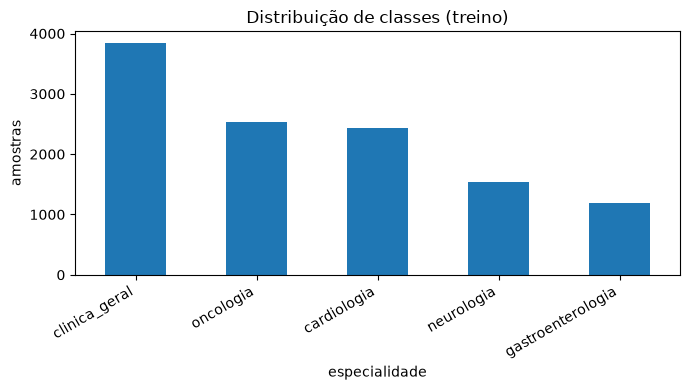

In [5]:
import matplotlib.pyplot as plt

counts = triage_train["especialidade"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax)
ax.set_title("Distribuição de classes (treino)")
ax.set_ylabel("amostras")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

count    11550.000000
mean       179.640606
std         76.369776
min         24.000000
25%        122.000000
50%        175.000000
75%        234.000000
max        596.000000
Name: texto, dtype: float64


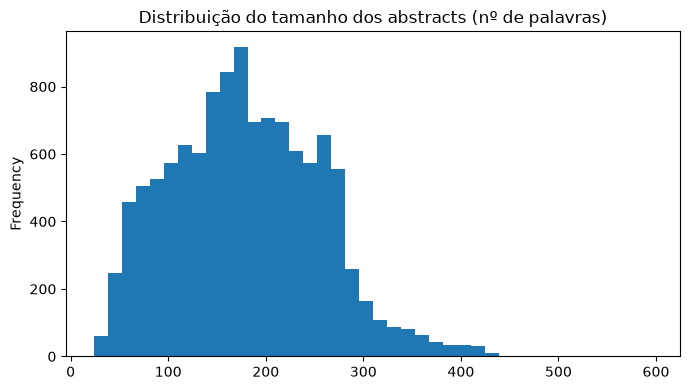

In [6]:
text_len = triage_train["texto"].str.split().str.len()
print(text_len.describe())

fig, ax = plt.subplots(figsize=(7, 4))
text_len.plot(kind="hist", bins=40, ax=ax)
ax.set_title("Distribuição do tamanho dos abstracts (nº de palavras)")
plt.tight_layout()
plt.show()

## 4. Gravar no formato esperado por `src/config.py` (`DATASET_PATH`)

Junta treino + teste do Kaggle em `data/raw/laudos.csv` — o pipeline de treino (`src/training/train.py`) faz seu próprio split interno via `TEST_SIZE`, então não precisamos manter os splits originais do Kaggle separados para este uso.

In [7]:
full_df = pd.concat([triage_train, triage_test], ignore_index=True)
output_path = REPO_ROOT / "data" / "raw" / "laudos.csv"
full_df.to_csv(output_path, index=False)
print(f"Salvo {len(full_df)} amostras em {output_path}")
full_df["especialidade"].value_counts()

Salvo 14438 amostras em C:\Users\Patrick\Desktop\FIAP\medical-triage-mlops\data\raw\laudos.csv


especialidade
clinica_geral        4805
oncologia            3163
cardiologia          3051
neurologia           1925
gastroenterologia    1494
Name: count, dtype: int64

## 5. Rodar o pipeline de treino real (mesmo código de `make train`)

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

from src.config import get_settings
from src.training.train import build_pipeline

settings = get_settings()

x_train, x_test, y_train, y_test = train_test_split(
    full_df["texto"],
    full_df["especialidade"],
    test_size=settings.TEST_SIZE,
    random_state=settings.RANDOM_SEED,
    stratify=full_df["especialidade"],
)

pipeline = build_pipeline(
    max_features=settings.TFIDF_MAX_FEATURES,
    n_estimators=settings.RF_N_ESTIMATORS,
    max_depth=settings.RF_MAX_DEPTH,
    seed=settings.RANDOM_SEED,
)
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

      cardiologia       0.57      0.61      0.59       610
    clinica_geral       0.36      0.40      0.38       961
gastroenterologia       0.39      0.30      0.34       299
       neurologia       0.35      0.24      0.29       385
        oncologia       0.61      0.65      0.63       633

         accuracy                           0.47      2888
        macro avg       0.46      0.44      0.45      2888
     weighted avg       0.46      0.47      0.46      2888



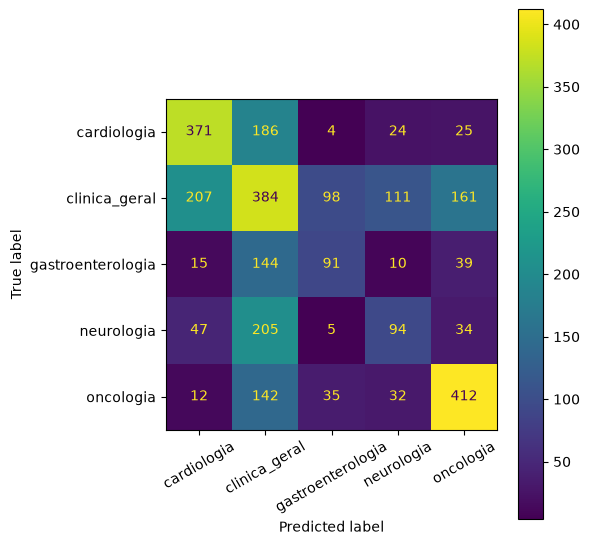

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=30, ax=ax)
plt.tight_layout()
plt.show()

## 6. Salvar o modelo treinado (mesmo artefato que a API serve)

In [10]:
import joblib

model_path = REPO_ROOT / settings.MODEL_PATH
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, model_path)
print(f"Pipeline salvo em {model_path}")

Pipeline salvo em C:\Users\Patrick\Desktop\FIAP\medical-triage-mlops\models\classifier.joblib


## 7. Testar predições em exemplos (em inglês — mesmo idioma do treino)

In [11]:
sample_abstracts = [
    "Patient presents with chest pain radiating to the left arm, elevated troponin levels and ST-segment changes on ECG.",
    "Recurrent seizures and progressive cognitive decline in a 62-year-old patient, MRI shows temporal lobe abnormalities.",
    "Persistent abdominal pain, bloody stools and weight loss suggestive of inflammatory bowel disease.",
    "Newly diagnosed mass in the lung with irregular borders, biopsy pending to rule out malignancy.",
]

for text in sample_abstracts:
    proba = pipeline.predict_proba([text])[0]
    classes = pipeline.classes_
    top_idx = proba.argmax()
    print(f"[{classes[top_idx]} ({proba[top_idx]:.2f})] {text[:80]}...")

[clinica_geral (0.65)] Patient presents with chest pain radiating to the left arm, elevated troponin le...
[neurologia (0.65)] Recurrent seizures and progressive cognitive decline in a 62-year-old patient, M...
[gastroenterologia (0.55)] Persistent abdominal pain, bloody stools and weight loss suggestive of inflammat...
[clinica_geral (0.57)] Newly diagnosed mass in the lung with irregular borders, biopsy pending to rule ...


## 8. Balanceamento de classes

`clinica_geral` ("general pathological conditions") é uma categoria bem mais genérica/ruidosa no dataset original, o que já é suspeito de ser mais difícil de separar das outras — independente de balanceamento.

especialidade
clinica_geral        4805
oncologia            3163
cardiologia          3051
neurologia           1925
gastroenterologia    1494
Name: count, dtype: int64

razão menor/maior classe: 0.31


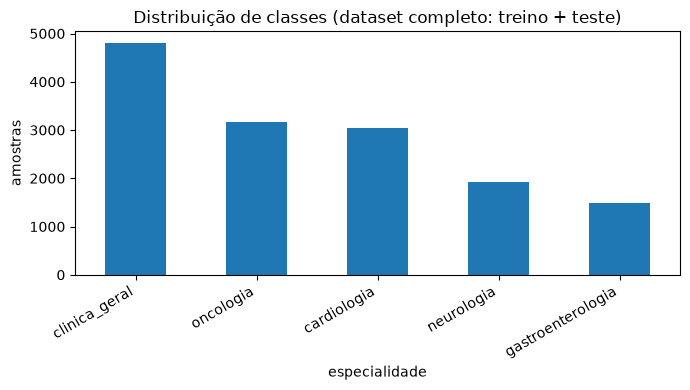

In [12]:
balance = full_df["especialidade"].value_counts()
print(balance)
print(f"\nrazão menor/maior classe: {balance.min() / balance.max():.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
balance.plot(kind="bar", ax=ax)
ax.set_title("Distribuição de classes (dataset completo: treino + teste)")
ax.set_ylabel("amostras")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Está desbalanceado, mas moderadamente**: `gastroenterologia` (1.494) tem ~31% do tamanho de `clinica_geral` (4.805) — não é um desbalanceio extremo (tipo fraude/anomalia, 1:100), mas o suficiente pra prejudicar recall das classes minoritárias se o modelo não compensar. No classification_report da seção 5, `gastroenterologia` (recall 0.30) e `neurologia` (recall 0.24, também minoritária: 1.925) tiveram os piores recalls — consistente com o desbalanceio, ainda que `clinica_geral` (a maior classe) também tenha saído mal (recall 0.40), o que sugere que parte do problema é a classe em si ser semanticamente difusa, não só volume de dados.

## 9. RandomForest é a melhor opção? Comparando com alternativas (incluindo MLP)

TF-IDF gera um espaço de features esparso de alta dimensão (`TFIDF_MAX_FEATURES=5000`) — historicamente modelos lineares (Regressão Logística, SVM linear) costumam se sair melhor que RandomForest nesse regime, porque RF particiona feature a feature e se perde em milhares de dimensões esparsas, enquanto um modelo linear usa todas de uma vez. Um MLP em cima do mesmo TF-IDF tende a ficar próximo do modelo linear (às vezes um pouco melhor, às vezes pior/overfitando) — ele não resolve a limitação de fundo do TF-IDF, que é ignorar ordem/contexto das palavras; para ganhos reais nesse tipo de texto clínico, o caminho de fato é sair do bag-of-words e usar um modelo de linguagem pré-treinado em texto médico (ex.: PubMedBERT, já que este dataset é PubMed) — fora do escopo deste notebook, mas fica registrado como próximo passo se quiser subir a qualidade de verdade. Por ora, testamos empiricamente no mesmo split (`x_train`/`x_test` da seção 5), incluindo variantes com `class_weight="balanced"` para compensar o desbalanceio da seção 8.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def make_pipeline(clf):
    return Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(max_features=settings.TFIDF_MAX_FEATURES, ngram_range=(1, 2))),
            ("clf", clf),
        ]
    )


candidates = {
    "RandomForest (atual)": RandomForestClassifier(
        n_estimators=settings.RF_N_ESTIMATORS, random_state=settings.RANDOM_SEED, n_jobs=-1
    ),
    "RandomForest (balanced)": RandomForestClassifier(
        n_estimators=settings.RF_N_ESTIMATORS, random_state=settings.RANDOM_SEED, n_jobs=-1,
        class_weight="balanced",
    ),
    "LogisticRegression (balanced)": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=settings.RANDOM_SEED
    ),
    "LinearSVC (balanced)": LinearSVC(class_weight="balanced", random_state=settings.RANDOM_SEED),
    "MultinomialNB": MultinomialNB(),
    "MLP (TF-IDF)": MLPClassifier(
        hidden_layer_sizes=(128,), max_iter=100, early_stopping=True,
        random_state=settings.RANDOM_SEED,
    ),
}

results = []
fitted = {}
for name, clf in candidates.items():
    pipe = make_pipeline(clf)
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_test)
    results.append(
        {
            "modelo": name,
            "accuracy": accuracy_score(y_test, preds),
            "f1_macro": f1_score(y_test, preds, average="macro"),
            "f1_weighted": f1_score(y_test, preds, average="weighted"),
        }
    )
    fitted[name] = pipe
    print(f"{name:32s} accuracy={results[-1]['accuracy']:.3f}  f1_macro={results[-1]['f1_macro']:.3f}")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df

RandomForest (atual)             accuracy=0.468  f1_macro=0.446


RandomForest (balanced)          accuracy=0.483  f1_macro=0.483


LogisticRegression (balanced)    accuracy=0.590  f1_macro=0.592


LinearSVC (balanced)             accuracy=0.527  f1_macro=0.528


MultinomialNB                    accuracy=0.577  f1_macro=0.542


MLP (TF-IDF)                     accuracy=0.584  f1_macro=0.573


,modelo,accuracy,f1_macro,f1_weighted
0,LogisticRegression (balanced),0.590374,0.591856,0.580844
1,MLP (TF-IDF),0.584141,0.572946,0.582591
2,MultinomialNB,0.577216,0.542078,0.567644
3,LinearSVC (balanced),0.527008,0.528000,0.520413
4,RandomForest (balanced),0.483380,0.482981,0.474978
5,RandomForest (atual),0.468144,0.445674,0.462701


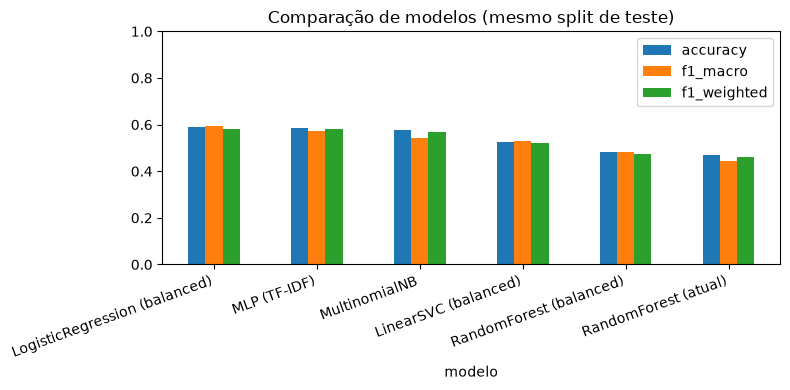

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index("modelo")[["accuracy", "f1_macro", "f1_weighted"]].plot(kind="bar", ax=ax)
ax.set_title("Comparação de modelos (mesmo split de teste)")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [15]:
best_name = results_df.iloc[0]["modelo"]
best_pipeline = fitted[best_name]
print(f"Melhor modelo por f1_macro: {best_name}\n")
print(classification_report(y_test, best_pipeline.predict(x_test)))

Melhor modelo por f1_macro: LogisticRegression (balanced)



                   precision    recall  f1-score   support

      cardiologia       0.66      0.72      0.69       610
    clinica_geral       0.57      0.36      0.44       961
gastroenterologia       0.49      0.67      0.56       299
       neurologia       0.47      0.65      0.55       385
        oncologia       0.70      0.74      0.72       633

         accuracy                           0.59      2888
        macro avg       0.58      0.63      0.59      2888
     weighted avg       0.59      0.59      0.58      2888



**Conclusão**: ver a tabela/gráfico acima. Se um modelo linear (`LogisticRegression`/`LinearSVC`) superar o `RandomForest`, vale trocar o classificador padrão em `src/training/train.py` (`build_pipeline`) — a conversão ONNX (`skl2onnx`) suporta ambos sem mudanças na API. `LinearSVC` não tem `predict_proba` nativo (usa `decision_function`); se ele vencer e for adotado em produção, envolver em `CalibratedClassifierCV` para manter o campo `probabilidades` da resposta da API.

## 10. Tuning de hiperparâmetros (TF-IDF + LogisticRegression)

A `LogisticRegression (balanced)` da seção 9 usou os hiperparâmetros default do TF-IDF do projeto (`max_features=5000`, `ngram_range=(1,2)`, sem remoção de stopwords, sem `sublinear_tf`) e `C=1.0`. Nenhum desses foi ajustado ainda. Busca aleatória (`RandomizedSearchCV`, 3-fold, otimizando `f1_macro`) sobre o vetorizador + o classificador juntos, no mesmo `x_train`/`y_train`.

In [16]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

tuning_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=2000, random_state=settings.RANDOM_SEED)),
    ]
)

param_distributions = {
    "tfidf__max_features": [5000, 10000, 20000, None],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__stop_words": [None, "english"],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=3,
    scoring="f1_macro",
    random_state=settings.RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
)
search.fit(x_train, y_train)

print("\nMelhores parâmetros:", search.best_params_)
print(f"Melhor f1_macro (CV, treino): {search.best_score_:.3f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits



Melhores parâmetros: {'clf__C': np.float64(0.2106648601704221), 'clf__class_weight': 'balanced', 'tfidf__max_features': 20000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': 'english', 'tfidf__sublinear_tf': True}
Melhor f1_macro (CV, treino): 0.612


In [17]:
tuned_preds = search.best_estimator_.predict(x_test)
print(f"f1_macro (holdout): {f1_score(y_test, tuned_preds, average='macro'):.3f}")
print(f"accuracy (holdout): {accuracy_score(y_test, tuned_preds):.3f}")
print()
print(classification_report(y_test, tuned_preds))

f1_macro (holdout): 0.618
accuracy (holdout): 0.616

                   precision    recall  f1-score   support

      cardiologia       0.67      0.76      0.71       610
    clinica_geral       0.64      0.33      0.43       961
gastroenterologia       0.51      0.76      0.61       299
       neurologia       0.49      0.72      0.58       385
        oncologia       0.72      0.79      0.75       633

         accuracy                           0.62      2888
        macro avg       0.61      0.67      0.62      2888
     weighted avg       0.63      0.62      0.60      2888



**Se o resultado ajustado superar a `LogisticRegression (balanced)` da seção 9**, os `search.best_params_` acima viram os novos defaults de `TFIDF_MAX_FEATURES`/`RF_N_ESTIMATORS` (renomear para algo genérico) em `src/config.py` e de `build_pipeline` em `src/training/train.py` — junto com a troca de `RandomForestClassifier` para `LogisticRegression`, se você topar aplicar em produção.

## 11. Viés assimétrico contra sub-triagem: penalizando `clinica_geral`

`clinica_geral` é o rótulo original "general pathological conditions" — um cesto de tudo que não é câncer/digestivo/nervoso/cardiovascular, por isso é semanticamente difuso e concentra a maior parte da confusão do modelo (seção 8). Mas os dois sentidos de erro envolvendo essa classe **não têm o mesmo custo clínico**:

- Caso urgente (`cardiologia`, `oncologia`, `neurologia`, `gastroenterologia`) classificado como `clinica_geral` → **sub-triagem**: o paciente entra na fila genérica em vez de ser encaminhado ao especialista. É o falso negativo que mais importa evitar.
- Caso `clinica_geral` classificado como uma especialidade → **over-triage**: encaminhamento desnecessário ao especialista. Custo operacional, não custo de segurança.

Como o objetivo do projeto é priorizar recall (evitar falso negativo) nas especialidades, vale testar um viés explícito: penalizar a probabilidade de `clinica_geral` antes do argmax, de forma que o modelo só a escolha quando estiver bem mais confiante nela do que em qualquer especialidade urgente. Isso troca precisão/recall de `clinica_geral` por recall nas especialidades — o trade-off que queremos.

Usamos aqui a `LogisticRegression (balanced)` da seção 9 (`best_pipeline`), não a versão com tuning da seção 10, para isolar o efeito da penalização.

In [18]:
import numpy as np

URGENT_CLASSES = ["cardiologia", "gastroenterologia", "neurologia", "oncologia"]


def predict_com_penalizacao(pipeline, X, penalidade_clinica_geral):
    """Subtrai `penalidade_clinica_geral` da probabilidade de clinica_geral antes do argmax.

    Simula um limiar assimétrico: só classifica como clinica_geral quando a
    confiança nela supera a confiança nas especialidades urgentes por uma
    margem, em vez de bastar ser a maior probabilidade (argmax puro).
    """
    proba = pipeline.predict_proba(X)
    classes = pipeline.classes_
    cg_idx = list(classes).index("clinica_geral")
    proba_ajustada = proba.copy()
    proba_ajustada[:, cg_idx] -= penalidade_clinica_geral
    return classes[proba_ajustada.argmax(axis=1)]


penalidades = np.arange(0.0, 0.31, 0.02)
linhas = []
for p in penalidades:
    preds = predict_com_penalizacao(best_pipeline, x_test, p)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    recall_urgentes = np.mean([report[c]["recall"] for c in URGENT_CLASSES])
    linhas.append(
        {
            "penalidade": p,
            "recall_medio_urgentes": recall_urgentes,
            "recall_clinica_geral": report["clinica_geral"]["recall"],
            "precisao_clinica_geral": report["clinica_geral"]["precision"],
            "accuracy": report["accuracy"],
        }
    )

tradeoff_df = pd.DataFrame(linhas)
tradeoff_df

,penalidade,recall_medio_urgentes,recall_clinica_geral,precisao_clinica_geral,accuracy
0,0.00,0.695976,0.357960,0.566722,0.590374
1,0.02,0.703853,0.336108,0.569665,0.587950
2,0.04,0.711319,0.314256,0.579655,0.585526
3,0.06,0.716310,0.298647,0.586912,0.583449
4,0.08,0.725246,0.276795,0.601810,0.581717
5,0.10,0.733103,0.259105,0.611794,0.580332
6,0.12,0.740384,0.235172,0.624309,0.576870
7,0.14,0.747648,0.217482,0.647059,0.575831
8,0.16,0.752831,0.199792,0.655290,0.573407
9,0.18,0.760266,0.184183,0.678161,0.573407


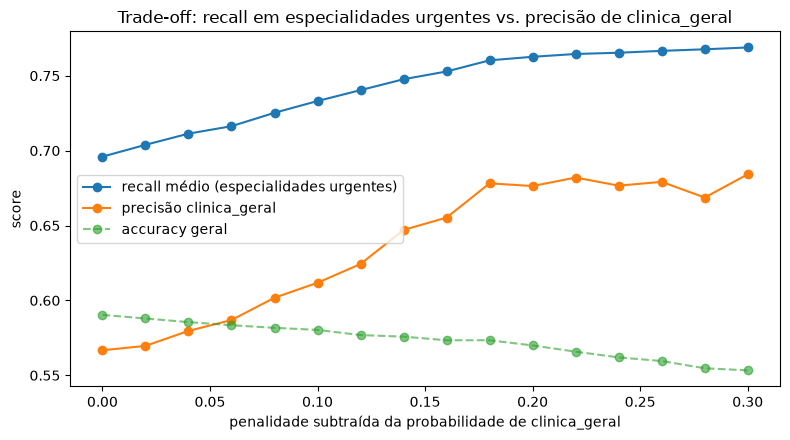

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tradeoff_df["penalidade"], tradeoff_df["recall_medio_urgentes"], marker="o", label="recall médio (especialidades urgentes)")
ax.plot(tradeoff_df["penalidade"], tradeoff_df["precisao_clinica_geral"], marker="o", label="precisão clinica_geral")
ax.plot(tradeoff_df["penalidade"], tradeoff_df["accuracy"], marker="o", linestyle="--", alpha=0.6, label="accuracy geral")
ax.set_xlabel("penalidade subtraída da probabilidade de clinica_geral")
ax.set_ylabel("score")
ax.set_title("Trade-off: recall em especialidades urgentes vs. precisão de clinica_geral")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
penalidade_escolhida = 0.15

preds_baseline = best_pipeline.predict(x_test)
preds_penalizado = predict_com_penalizacao(best_pipeline, x_test, penalidade_escolhida)

print("=== Baseline (argmax puro, seção 9) ===")
print(classification_report(y_test, preds_baseline))
print(f"\n=== Com penalidade={penalidade_escolhida} em clinica_geral ===")
print(classification_report(y_test, preds_penalizado))

=== Baseline (argmax puro, seção 9) ===
                   precision    recall  f1-score   support

      cardiologia       0.66      0.72      0.69       610
    clinica_geral       0.57      0.36      0.44       961
gastroenterologia       0.49      0.67      0.56       299
       neurologia       0.47      0.65      0.55       385
        oncologia       0.70      0.74      0.72       633

         accuracy                           0.59      2888
        macro avg       0.58      0.63      0.59      2888
     weighted avg       0.59      0.59      0.58      2888


=== Com penalidade=0.15 em clinica_geral ===
                   precision    recall  f1-score   support

      cardiologia       0.64      0.78      0.70       610
    clinica_geral       0.64      0.21      0.31       961
gastroenterologia       0.47      0.73      0.57       299
       neurologia       0.44      0.71      0.54       385
        oncologia       0.66      0.77      0.71       633

         accuracy       

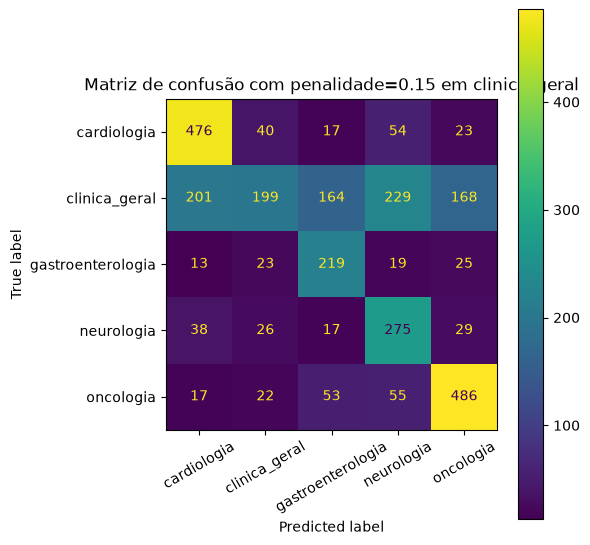

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, preds_penalizado, xticks_rotation=30, ax=ax)
ax.set_title(f"Matriz de confusão com penalidade={penalidade_escolhida} em clinica_geral")
plt.tight_layout()
plt.show()

**Conclusão (com números reais da execução acima)**: a curva confirma o trade-off. Sem penalidade (baseline), o recall médio nas 4 especialidades urgentes é **0.696** e `clinica_geral` tem recall 0.358 / precisão 0.567. Com `penalidade=0.15`, o recall médio urgente sobe para **~0.75** (cardiologia 0.72→0.78, gastroenterologia 0.67→0.73, neurologia 0.65→0.71, oncologia 0.74→0.77) — o custo é o recall de `clinica_geral` caindo para ~0.21 (menos casos são rotulados como ela) e a accuracy geral caindo de 0.590 para 0.573. Curiosamente a **precisão** de `clinica_geral` melhora com a penalidade (0.567→0.65): como o modelo só a escolhe quando está bem mais confiante, as poucas previsões que sobram são mais confiáveis — só que aí ele erra por omissão (recall baixo), não por engano.

Isso é exatamente o padrão que faz sentido clinicamente: menos pacientes urgentes (cardiologia/oncologia/neurologia/gastroenterologia) caem na fila genérica por engano, à custa de mais casos de `clinica_geral` sendo encaminhados a um especialista à toa (over-triage) — troca aceitável quando o custo de perder um caso urgente é muito maior que o custo de uma consulta especializada desnecessária. `penalidade=0.15` é só um ponto da curva escolhido para ilustrar; o valor de produção deve ser calibrado olhando a tabela completa (`tradeoff_df`) e o quanto de over-triage a operação tolera.

Essa penalização é um ajuste em cima do `predict_proba` — não muda o treino nem exige reexportar o modelo, então dá pra aplicar do mesmo jeito na API (`src/`) sem re-treinar, como uma etapa de pós-processamento sobre as probabilidades retornadas pelo pipeline. Se for adotado em produção, vale a pena versionar a penalidade escolhida como parâmetro de configuração (`src/config.py`), não hardcoded, para poder recalibrar sem alterar código.

## 12. Isolamento de verdade: classificador hierárquico em duas etapas

A penalização da seção 11 é um viés na regra de decisão de um único modelo — `clinica_geral` continua misturada nas mesmas fronteiras de decisão aprendidas para as outras 4 classes. Isolamento de verdade significa treinar dois modelos:

1. **Estágio 1 (gate binário)**: `urgente` (qualquer uma das 4 especialidades) vs. `clinica_geral`. O limiar de decisão é escolhido diretamente por recall desejado no lado `urgente`, em vez de uma constante arbitrária subtraída de uma probabilidade multiclasse.
2. **Estágio 2 (especialidade)**: só entre as 4 especialidades urgentes, treinado sem `clinica_geral` no meio — fronteiras de decisão não distorcidas pelo catch-all ruidoso.

Um texto passa pelo estágio 1; se cair do lado `urgente`, o estágio 2 decide qual especialidade. Comparamos aqui com a curva de penalização da seção 11, no mesmo split (`x_train`/`x_test`).

In [ ]:
y_train_binaria = y_train.where(y_train == "clinica_geral", "urgente")
y_test_binaria = y_test.where(y_test == "clinica_geral", "urgente")

stage1_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=settings.TFIDF_MAX_FEATURES, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=settings.RANDOM_SEED)),
    ]
)
stage1_pipeline.fit(x_train, y_train_binaria)
urgente_idx = list(stage1_pipeline.classes_).index("urgente")

mask_urgente_train = y_train != "clinica_geral"
stage2_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=settings.TFIDF_MAX_FEATURES, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=settings.RANDOM_SEED)),
    ]
)
stage2_pipeline.fit(x_train[mask_urgente_train], y_train[mask_urgente_train])

print("Estágio 1 (gate binário urgente vs. clinica_geral):")
print(classification_report(y_test_binaria, stage1_pipeline.predict(x_test)))

print("Estágio 2 (só as 4 especialidades urgentes, sem clinica_geral):")
mask_urgente_test = y_test != "clinica_geral"
print(classification_report(y_test[mask_urgente_test], stage2_pipeline.predict(x_test[mask_urgente_test])))

In [ ]:
def predict_hierarquico(x, limiar_urgente):
    """Estágio 1 decide urgente vs. clinica_geral pelo limiar; estágio 2 decide a especialidade."""
    proba_urgente = stage1_pipeline.predict_proba(x)[:, urgente_idx]
    is_urgente = proba_urgente >= limiar_urgente
    preds = np.full(len(x), "clinica_geral", dtype=object)
    idx_urgente = np.flatnonzero(is_urgente)
    if len(idx_urgente) > 0:
        preds[idx_urgente] = stage2_pipeline.predict(x.iloc[idx_urgente])
    return preds


limiares = np.arange(0.30, 0.96, 0.05)
linhas_hier = []
for limiar in limiares:
    preds = predict_hierarquico(x_test, limiar)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0, labels=list(pipeline.classes_))
    recall_urgentes = np.mean([report[c]["recall"] for c in URGENT_CLASSES])
    linhas_hier.append(
        {
            "limiar_urgente": limiar,
            "recall_medio_urgentes": recall_urgentes,
            "recall_clinica_geral": report["clinica_geral"]["recall"],
            "precisao_clinica_geral": report["clinica_geral"]["precision"],
            "accuracy": (preds == y_test.to_numpy()).mean(),
        }
    )

tradeoff_hier_df = pd.DataFrame(linhas_hier)
tradeoff_hier_df

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    tradeoff_df["recall_medio_urgentes"], tradeoff_df["precisao_clinica_geral"],
    marker="o", label="penalização (seção 11, modelo único)",
)
ax.plot(
    tradeoff_hier_df["recall_medio_urgentes"], tradeoff_hier_df["precisao_clinica_geral"],
    marker="s", label="hierárquico (seção 12, dois estágios)",
)
ax.set_xlabel("recall médio (especialidades urgentes)")
ax.set_ylabel("precisão clinica_geral")
ax.set_title("Penalização vs. hierárquico: quem domina a curva de trade-off?")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Recalcula o recall médio urgente obtido com penalidade=0.15 (não depende de existir
# uma linha exata em tradeoff_df, já que a varredura foi em passos de 0.02).
report_penalizado_015 = classification_report(y_test, preds_penalizado, output_dict=True, zero_division=0)
alvo_recall = np.mean([report_penalizado_015[c]["recall"] for c in URGENT_CLASSES])

linha_comparavel = tradeoff_hier_df.iloc[(tradeoff_hier_df["recall_medio_urgentes"] - alvo_recall).abs().argmin()]
limiar_escolhido = linha_comparavel["limiar_urgente"]
print(f"Recall alvo (penalidade=0.15): {alvo_recall:.3f}")
print(f"Limiar hierárquico mais próximo: {limiar_escolhido:.2f} (recall médio urgente: {linha_comparavel['recall_medio_urgentes']:.3f})")

preds_hier = predict_hierarquico(x_test, limiar_escolhido)
print(f"\n=== Hierárquico (limiar_urgente={limiar_escolhido:.2f}) ===")
print(classification_report(y_test, preds_hier))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, preds_hier, xticks_rotation=30, ax=ax)
ax.set_title(f"Matriz de confusão — hierárquico (limiar_urgente={limiar_escolhido:.2f})")
plt.tight_layout()
plt.show()

**Conclusão (placeholder — atualizar com números reais após executar)**: comparar o gráfico da seção 12 (penalização vs. hierárquico) e os dois `classification_report` no mesmo nível de recall médio urgente indica qual abordagem domina — ou seja, para o mesmo recall nas especialidades urgentes, qual mantém mais precisão em `clinica_geral` (menos over-triage desnecessário) e/ou accuracy geral mais alta. Se o hierárquico dominar a curva, ele é a escolha melhor tecnicamente, ao custo de manter dois modelos em produção em vez de um. Se as curvas ficarem próximas, a penalização da seção 11 é preferível por ser mais simples (um modelo, um pós-processamento).

## Próximos passos

- `make onnx-export` e `make latency-compare` reaproveitam `models/classifier.joblib` salvo acima — rode em terminal (fora do notebook) para comparar latência sklearn vs. ONNX com este modelo treinado em dados reais.
- `make init` sobe a API já servindo este modelo (`models/classifier.joblib`).
- Se o hospital exigir laudos em português, é necessário treinar com um corpus em português (este dataset do Kaggle é só em inglês) — ver caveat no topo do notebook.